In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy import stats
import math as mt
import warnings
warnings.filterwarnings("ignore")
from iminuit import Minuit

# QUESTION1. Cash or CStat statistic problem
Assume you measured $n_{on}$ counts in a region where you think a source might be present. If the expected number of background events, $n_{bkg}$ is known, derive the Maximum Likelihood Estimate for the expected number of signal counts from the region. This is commonly known as Cash or CStat statistic.

- For $n_{on} = 10$ and $n_{bkg} = 3$, calculate the excess, significance of detection and the $1\sigma$ and $2\sigma$ confidence intervals for the excess. Plot the likelihood profiles.

- For $n_{on} = 5$ and $n_{bkg} = 3$, calculate the excess, significance of detection and the $5\sigma$ upper limit on the excess. Plot the likelihood profiles.


## ANSWER 1:
Let the expected number of signal counts be $n_s$, and given $n_{bkg}$, we use the fact that the sum of two independent Poisson random variables is also Poisson distributed with mean equal to the sum of their means. Thus, the likelihood for observing $n_{on}$ counts is:
$$
\mathcal{L} = \frac{(n_s+n_{bkg})^{n_{on}} e^{-(n_s+n_{bkg})}}{n_{on}!}
$$

Defining the negative log-likelihood as $C = -\ln \mathcal{L}$, we obtain:
$$
C = n_s - n_{on}\ln (n_s+n_{bkg}) + \ell
$$
where $\ell$ denotes that the remaining terms are constant with respect to $n_s$. This is useful because, while obtaining the Maximum Likelihood Estimate (MLE), we need to minimize $C$, and upon differentiation with respect to $n_s$, the constant term $\ell$ drops out.

Thus, denoting the MLE for $n_s$ as $\hat{n}_s$, we have:

\begin{align}
\left(\frac{\partial C}{\partial n_{s}}\right)_{n_s = \hat{n}_s} &= 0 \nonumber\\
\implies 1 - \frac{n_{on}}{\hat{n}_s+n_{bkg}} &= 0 \nonumber\\
\implies \hat{n}_s &= n_{on}-n_{bkg}
\end{align}

Finally, imposing the physical constraint that the signal cannot be negative, the estimator becomes:
$$
\hat{n}_s = \max(0,\; n_{on}-n_{bkg})
$$


Let the expected number of signal counts be $n_s$, with known background $n_{bkg}$. The Maximum Likelihood Estimate is given by $\hat{n}_s = n_{on} - n_{bkg}$.

To test the null hypothesis $n_s = 0$, we define the likelihood ratio test statistic:
$$
\lambda = 2 \left[ C(n_s = 0) - C(\hat{n}_s) \right]
$$

Substituting the expression for $C$ and simplifying (noting that constant terms cancel), we obtain:
\begin{align}
\lambda &= 2\left[-n_{on}\ln (n_{bkg}) - \left(\hat{n}_s - n_{on}\ln (\hat{n}_s+n_{bkg})\right)\right] \nonumber\\
&= -2\left(\hat{n}_s + n_{on}\ln\left(\frac{n_{bkg}}{\hat{n}_s+n_{bkg}}\right)\right)
\end{align}

Under the null hypothesis, Wilks’ theorem states that $\lambda$ follows a $\chi^2$ distribution with 1 degree of freedom (d.o.f), where the degree of freedom corresponds to the number of free parameters (here, $n_s$).

The $p$-value is defined as:
$$
p = \int_{\lambda}^{\infty} f_{\chi^2_1}(x)\, dx
$$

where $f_{\chi^2_1}(x)$ is the probability density function of the $\chi^2$ distribution with 1 d.o.f:
$$
f_{\chi^2_1}(x) = \frac{1}{\sqrt{2\pi x}} e^{-x/2}
$$

The statistical significance is defined in terms of the standard normal distribution as:
$$
S = \Phi^{-1}(1 - p)
$$

where $\Phi$ is the cumulative distribution function (CDF) of the standard normal distribution:
$$
\Phi(S) = \int_{-\infty}^{S} \frac{1}{\sqrt{2\pi}} e^{-z^2/2} \, dz
$$

Thus,
$$
1 - p = \Phi(S)
$$

Now, for a $\chi^2$ distribution with 1 d.o.f, the following identity holds:
$$
p = \int_{\lambda}^{\infty} f_{\chi^2_1}(x)\, dx = \int_{\sqrt{\lambda}}^{\infty} \frac{1}{\sqrt{2\pi}} e^{-z^2/2} \, dz
$$

which implies:
$$
p = 1 - \Phi(\sqrt{\lambda})
$$

Therefore,
$$
1 - p = \Phi(\sqrt{\lambda})
$$

Comparing with $1 - p = \Phi(S)$, we obtain:
$$
S = \sqrt{\lambda}
$$

Hence, the statistical significance is:
$$
\boxed{S = \sqrt{2 \left[ C(0) - C(\hat{n}_s) \right]}}
$$

This provides the direct relation between the likelihood ratio test statistic and the Gaussian significance.

## Confidence Intervals using Likelihood Profile (CStat)

The confidence intervals on the signal parameter $n_s$ are obtained from the likelihood profile. The negative log-likelihood is

$$
C(n_s) = -\ln \mathcal{L}(n_s)
$$

and the best-fit value $\hat{n}_s$ is the value that minimizes $C(n_s)$.

To construct the confidence interval, we compare a trial value $n_s$ with the best-fit value $\hat{n}_s$ using the likelihood-ratio statistic:

$$
q(n_s) = -2\ln\left(\frac{\mathcal{L}(n_s)}{\mathcal{L}(\hat{n}_s)}\right)
$$

Using $C(n_s) = -\ln \mathcal{L}(n_s)$, this becomes

$$
q(n_s) = 2\left[C(n_s)-C(\hat{n}_s)\right]
$$

Therefore, if we define

$$
\Delta C = C(n_s)-C(\hat{n}_s)
$$

then

$$
q(n_s)=2\Delta C
$$

For one free parameter, Wilks’ theorem states that the likelihood-ratio statistic follows a chi-square distribution with one degree of freedom:

$$
q(n_s)\sim \chi^2_1
$$

Hence,

$$
2\Delta C \sim \chi^2_1
$$

Thus, the confidence intervals correspond to fixed values of $\Delta C$.

For a $1\sigma$ interval, the corresponding chi-square value for one degree of freedom is

$$
\chi^2_1 = 1
$$

so

$$
2\Delta C = 1
$$

and therefore

$$
\Delta C = \frac{1}{2}
$$

For a $2\sigma$ interval, the corresponding chi-square value for one degree of freedom is

$$
\chi^2_1 = 4
$$

so

$$
2\Delta C = 4
$$

and therefore

$$
\Delta C = 2
$$

Therefore, the confidence interval is obtained by solving

$$
C(n_s) = C(\hat{n}_s) + \Delta C
$$

For the CStat likelihood, ignoring constants independent of $n_s$,

$$
C(n_s)=n_s-n_{on}\ln(n_s+n_{bkg})
$$

Hence, the interval bounds are obtained from

$$
n_s - n_{on}\ln(n_s + n_{bkg})
=
\hat{n}_s - n_{on}\ln(\hat{n}_s + n_{bkg}) + \Delta C
$$

This equation is generally solved numerically to obtain the lower and upper bounds of $n_s$.

---

## Summary

- Best fit: $n_s = \hat{n}_s$
- $1\sigma$: solve $\Delta C = 1/2$
- $2\sigma$: solve $\Delta C = 2$

The solutions give the confidence interval:

$$
n_s \in [n_s^{\text{low}},\, n_s^{\text{high}}]
$$
## Likelihood Profile 

 The background $n_{bkg}$ is known. Therefore, the likelihood depends only on one unknown parameter, the signal counts $n_s$.

The likelihood is

$$
\mathcal{L}(n_s)
=
\frac{(n_s+n_{bkg})^{n_{on}}e^{-(n_s+n_{bkg})}}{n_{on}!}.
$$

$$
\mathcal{L}_{profile}(n_s)=\mathcal{L}(n_s).
$$

To plot the likelihood profile, we usually normalize it by dividing by its maximum value. The maximum occurs at

$$
\hat{n}_s = n_{on}-n_{bkg}.
$$

The negative log-likelihood is

$$
C(n_s)=n_s-n_{on}\ln(n_s+n_{bkg})+\ell,
$$

where $\ell$ is constant with respect to $n_s$.

The likelihood-ratio statistic is

$$
q(n_s)
=
2\left[C(n_s)-C(\hat{n}_s)\right].
$$

The normalized profile likelihood is then

$$
\mathcal{L}_{profile}(n_s)
=
\exp\left[-\frac{q(n_s)}{2}\right].
$$

This quantity is equal to 1 at the best-fit value $\hat{n}_s$ and decreases as $n_s$ moves away from the best fit.



$$
\mathcal{L}_{profile}(n_s)=e^{-q(n_s)/2}.
$$

 Plot $\mathcal{L}_{profile}(n_s)$ versus $n_s$.

The peak of the plot gives the best-fit excess $\hat{n}_s$, and the width of the curve gives the uncertainty on the signal counts.


## Nmerical calculation for $n_{on}=10$ and $n_{bkg}=3$ 
This calculation is carried out in the code block below: for excess, significance of detection and 1 and 2-sigma confidence interval 

In [19]:
# Given observed ON counts and known background counts
n_on = 10.0
n_bkg = 3.0

# Maximum Likelihood Estimate of signal counts
# For CStat with known background:
# n_s_hat = n_on - n_bkg
n_s_hat = n_on - n_bkg

# Physical excess cannot be negative
excess = max(0.0, n_s_hat)

# Likelihood-ratio test statistic for null hypothesis n_s = 0
# lambda = 2[C(0) - C(n_s_hat)]
#        = -2[n_s_hat + n_on ln(n_bkg / (n_s_hat + n_bkg))]
lambda_0 = -2.0 * (
    n_s_hat + n_on * np.log(n_bkg / (n_s_hat + n_bkg))
)

# Under Wilks' theorem, lambda_0 follows chi-square distribution with 1 d.o.f
p_value_two_sided = 1.0 - sp.stats.chi2.cdf(lambda_0, df=1)

# For detection significance we need one-sided Gaussian probability
p_value_one_sided = p_value_two_sided / 2.0

# Convert one-sided p-value to Gaussian significance
# norm.isf(p) gives Phi^{-1}(1-p)
detection_sig = sp.stats.norm.isf(p_value_one_sided)

print(f"Excess: {excess:.2f}")
print(f"Test statistic lambda: {lambda_0:.2f}")
print(f"significance of detection: {detection_sig:.2f} sigma")

Excess: 7.00
Test statistic lambda: 10.08
significance of detection: 3.17 sigma


Best-fit excess: 7.00
1 sigma confidence interval for n_s: [4.16, 10.49]
2 sigma confidence interval for n_s: [1.94, 14.71]


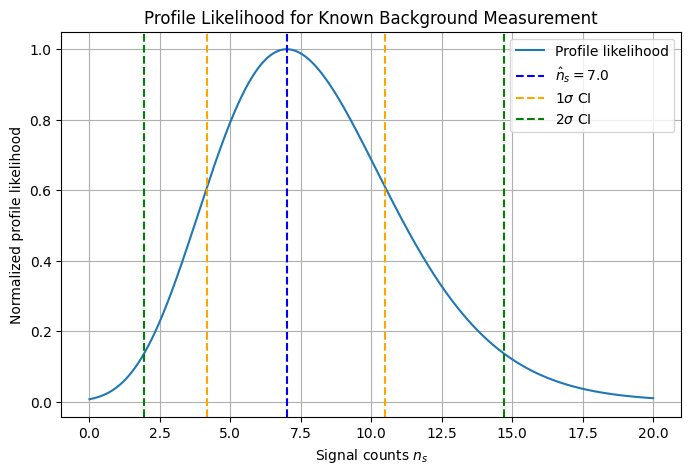

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Given observed ON counts and known background counts
n_on = 10.0
n_bkg = 3.0

# Best-fit signal counts from the CStat MLE
n_s_hat = max(0.0, n_on - n_bkg)

# Negative log-likelihood for CStat
# Ignoring constants independent of n_s:
# C(n_s) = n_s - n_on ln(n_s + n_bkg)
def C_stat(n_s, n_on, n_bkg):
    return n_s - n_on * np.log(n_s + n_bkg)

# Signal-count grid
n_s_vals = np.linspace(0, 20, 1000)

# Likelihood-ratio statistic:
# q(n_s) = 2[C(n_s) - C(n_s_hat)]
# By Wilks' theorem, q(n_s) ~ chi^2_1
q_vals = 2.0 * (C_stat(n_s_vals, n_on, n_bkg) - C_stat(n_s_hat, n_on, n_bkg))

# Profile likelihood normalized to 1 at best fit
profile_likelihood = np.exp(-0.5 * q_vals)

# 1 sigma interval:
# q(n_s) = 1  <=>  Delta C = 1/2
ci_1sigma = n_s_vals[q_vals <= 1.0]

# 2 sigma interval:
# q(n_s) = 4  <=>  Delta C = 2
ci_2sigma = n_s_vals[q_vals <= 4.0]

print(f"Best-fit excess: {n_s_hat:.2f}")
print(f"1 sigma confidence interval for n_s: [{ci_1sigma[0]:.2f}, {ci_1sigma[-1]:.2f}]")
print(f"2 sigma confidence interval for n_s: [{ci_2sigma[0]:.2f}, {ci_2sigma[-1]:.2f}]")

# Plot the profile likelihood
plt.figure(figsize=(8, 5))
plt.plot(n_s_vals, profile_likelihood, label="Profile likelihood")

# Best-fit value
plt.axvline(n_s_hat, color="blue", linestyle="--", label=rf"$\hat{{n}}_s = {n_s_hat:.1f}$")

# 1 sigma confidence interval
plt.axvline(ci_1sigma[0], color="orange", linestyle="--", label=r"$1\sigma$ CI")
plt.axvline(ci_1sigma[-1], color="orange", linestyle="--")

# 2 sigma confidence interval
plt.axvline(ci_2sigma[0], color="green", linestyle="--", label=r"$2\sigma$ CI")
plt.axvline(ci_2sigma[-1], color="green", linestyle="--")

plt.xlabel(r"Signal counts $n_s$")
plt.ylabel("Normalized profile likelihood")
plt.title("Profile Likelihood for Known Background Measurement")
plt.legend()
plt.grid(True)
plt.show()

## Now, for the case of $n_{on} = 5$, $n_{bkg}= 3$, the excess is $\hat{n}_s = 5 - 3 = 2$

In [21]:
# Given observed ON counts and known background counts
n_on = 5.0
n_bkg = 3.0

# Maximum Likelihood Estimate of signal counts
# n_s_hat = n_on - n_bkg
n_s_hat = n_on - n_bkg

# Physical constraint: signal cannot be negative
excess = max(0.0, n_s_hat)

# Likelihood-ratio test statistic:
# lambda = 2[C(0) - C(n_s_hat)]
#        = -2[n_s_hat + n_on ln(n_bkg / (n_s_hat + n_bkg))]
lambda_0 = -2.0 * (
    n_s_hat + n_on * np.log(n_bkg / (n_s_hat + n_bkg))
)

# Under Wilks' theorem: lambda ~ chi^2 with 1 d.o.f
p_two_sided = 1.0 - sp.stats.chi2.cdf(lambda_0, df=1)

# Convert to one-sided p-value (for detection significance)
p_one_sided = p_two_sided / 2.0

# Convert p-value to Gaussian significance
# norm.isf(p) = Phi^{-1}(1 - p)
detection_sig = sp.stats.norm.isf(p_one_sided)

print(f"Excess: {excess:.2f}")
print(f"Test statistic lambda: {lambda_0:.2f}")
print(f"Detection significance: {detection_sig:.2f} sigma")

Excess: 2.00
Test statistic lambda: 1.11
Detection significance: 1.05 sigma


 ## Likelihood profile and $5-\sigma$ upper limit 


### Why a 5$\sigma$ Upper Limit is Required in this Case

For the case $n_{on} = 5$ and $n_{bkg} = 3$, the estimated signal is:
$$
\hat{n}_s = 2
$$

However, the corresponding statistical significance is only $\sim 1\sigma$, which is consistent with background fluctuations. Therefore, the observed excess is not statistically significant.

In this regime, the likelihood function is broad and asymmetric due to the Poisson nature of the data, and the signal strength is poorly constrained. Many values of $n_s$ remain compatible with the observed data.

As a result, quoting only the best-fit value $\hat{n}_s$ is misleading. Instead, it is more appropriate to place an upper limit on the signal strength.

## 5$\sigma$ Upper Limit on Signal Counts

When the observed excess is not statistically significant, it is not appropriate to claim a detection. Instead, we place an upper limit on the signal strength. This ensures that we quantify the maximum possible signal consistent with the observed data.

In high-energy and gamma-ray astrophysics, a $5\sigma$ threshold is used as the standard criterion for discovery. This corresponds to an extremely small probability ($p \sim 3 \times 10^{-7}$) that a background fluctuation mimics a signal. Therefore, if the observed significance is below $5\sigma$, we do not claim detection and instead report an upper limit.




The likelihood-ratio statistic is defined as:
$$
q(n_s) = 2 \left[ C(n_s) - C(\hat{n}_s) \right]
$$

According to Wilks’ theorem, for one free parameter:
$$
q(n_s) \sim \chi^2_1
$$

The statistical significance is related to the test statistic by:
$$
S = \sqrt{q}
$$



### 5$\sigma$ Condition

To define a $5\sigma$ upper limit, we require:
$$
S = 5
$$

which implies:
$$
q = S^2 = 25
$$

Since
$$
q = 2\Delta C
$$

we obtain:
$$
2\Delta C = 25 \;\Rightarrow\; \Delta C = \frac{25}{2}
$$



### Final Equation

Thus, the upper limit $n_s^{UL}$ is obtained by solving:
$$
C(n_s^{UL}) = C(\hat{n}_s) + \frac{25}{2}
$$

Using the explicit form of $C(n_s)$:
$$
n_s^{UL} - n_{on}\ln(n_s^{UL} + n_{bkg})
=
\hat{n}_s - n_{on}\ln(\hat{n}_s + n_{bkg}) + \frac{25}{2}
$$

This equation is solved numerically to obtain the $5\sigma$ upper limit.



### Interpretation

The $5\sigma$ upper limit represents the maximum signal strength that is still consistent with the observed data without reaching the discovery threshold. This prevents false claims of detection due to statistical fluctuations while still constraining the possible signal.



Best-fit excess: 2.00
5 sigma upper limit on n_s: 22.67


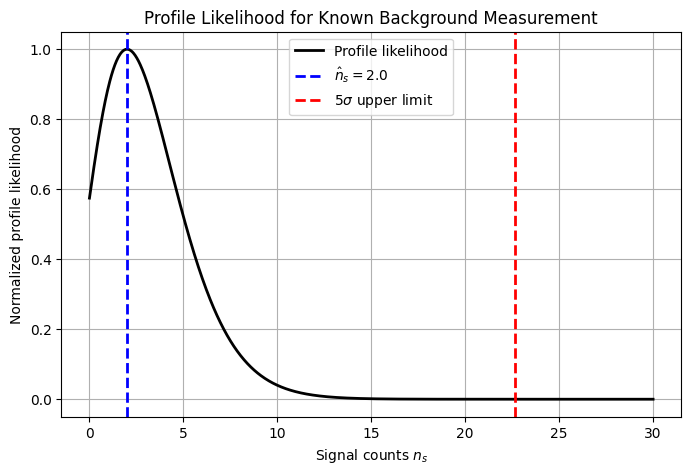

In [22]:
n_on = 5.0
n_bkg = 3.0

# MLE for signal
n_s_hat = max(0.0, n_on - n_bkg)

# CStat negative log-likelihood
def C_stat(n_s, n_on, n_bkg):
    return n_s - n_on * np.log(n_s + n_bkg)

# Grid
n_s_grid = np.linspace(0, 30, 1000)

# Likelihood-ratio statistic
q_n_s = 2.0 * (C_stat(n_s_grid, n_on, n_bkg) - C_stat(n_s_hat, n_on, n_bkg))

# Profile likelihood
profile_likelihood = np.exp(-0.5 * q_n_s)

# 5 sigma UL condition: q <= 25
allowed_5sigma = n_s_grid[q_n_s <= 25.0]
n_s_ul_5sigma = allowed_5sigma[-1]

print(f"Best-fit excess: {n_s_hat:.2f}")
print(f"5 sigma upper limit on n_s: {n_s_ul_5sigma:.2f}")

# Plot
plt.figure(figsize=(8, 5))

# Profile likelihood (black)
plt.plot(n_s_grid, profile_likelihood, color='black', linewidth=2, label="Profile likelihood")

# Best-fit (blue)
plt.axvline(n_s_hat, color='blue', linestyle='--', linewidth=2,
            label=rf"$\hat{{n}}_s = {n_s_hat:.1f}$")

# 5 sigma UL (red)
plt.axvline(n_s_ul_5sigma, color='red', linestyle='--', linewidth=2,
            label=r"$5\sigma$ upper limit")

# Labels
plt.xlabel(r"Signal counts $n_s$")
plt.ylabel("Normalized profile likelihood")
plt.title("Profile Likelihood for Known Background Measurement")

plt.legend()
plt.grid(True)
plt.show()

# Question2. WStat Statistic 

Same as above, but instead of having a model predicted number of background events, you have measured $n_{off}$ counts in a background control region where you assume no source is present. The off region is twice as large as the on region, so $\alpha = \alpha_{on}/\alpha_{off} = 1/2$. Likelihood Estimate for the expected number of signal counts from the region. This is commonly known as WStat statistic.

- For $n_{on} = 10$ and $n_{off} = 6$, calculate the excess, significance of detection and the $1\sigma$ and $2\sigma$ confidence intervals for the excess. Plot the likelihood profiles.

- For $n_{on} = 5$ and $n_{off} = 6$, calculate the excess, significance of detection and the $5\sigma$ upper limit on the excess. Plot the likelihood profiles.

- Comment on the differences between the two likelihoods.

## ANSWER 2 
**At first of all we think $N_{on} $ and $N_{off} $ are observed count so they become 10 and 6 or 5 and 6 but $n_{on}$ and $n_{off}$ is mean of distribution. This is a notation we used in this derivation. so we interchange them.**


Here, the expected background during the ON measurement is not known a priori. Instead, it is estimated using an independent OFF-region measurement.

Let $t_{on}$ and $t_{off}$ be the observation times for the ON and OFF regions respectively. Let $N_{on}$ and $N_{off}$ be the corresponding observed counts.

The OFF region contains only background events, so $N_{off}$ follows a Poisson distribution with mean $n_{off}$, where $n_{off}$ is the expected number of background counts in the OFF region.

Assuming that the background rate is constant during both ON and OFF observations, the background rate is

$$
r_b = \frac{n_{off}}{t_{off}}.
$$

Therefore, the expected background counts in the ON region are $ n_{bkg,on} = r_b\, t_{on} = \frac{n_{off}}{t_{off}}\, t_{on}$. Defining $ \alpha = \frac{t_{on}}{t_{off}}$, we obtain $ n_{bkg,on} = \alpha n_{off}$.

So, the likelihood of observing the data would be:
$$
\mathcal{L}(n_s, n_{off}) = \frac{n_{on}^{N_{on}}e^{-n_{on}}}{N_{on}!} \frac{n_{off}^{N_{off}}e^{-n_{off}}} {N_{off}!}
$$
where $n_{on}$ is the expected source on-time measurement, and the factor corresponding to off-time measurement comes in due to it being an independent one from the on-time measurement. Since we model the counts in the on region being due to both the signal and the background, we would have the expected value of counts during $t_{on}$ to be $n_{on} = n_{s}+n_{bkg,on}$, where $n_{s}$ is the expected counts due to the source. This is possible because the sum of two Poissonian random variables being a Possion random variable with the mean the same as the sum of their individual means. So, we have:
$$
\mathcal{L}(n_s, n_{off}) = \frac{(n_{s}+\alpha n_{off})^{N_{on}}e^{-(n_{s}+\alpha n_{off})}}{N_{on}!}\frac{n_{off}^{N_{off}}e^{-n_{off}}} {N_{off}!}
$$

Following the convention used in Question 1, we define negative log-likelihood
$$
C = -\ln \mathcal{L}.
$$

Ignoring terms independent of $n_s$ and $n_{off}$, we obtain

$$
C(n_s, n_{off})
=
n_s + \alpha n_{off}
-
N_{on} \ln(n_s + \alpha n_{off})
+
n_{off}
-
N_{off} \ln n_{off}
+
\ell,
$$

where $\ell$ is constant with respect to the parameters and does not affect the minimization.

To obtain the Maximum Likelihood Estimation, we minimize $C$.

## Derivative with respect to $n_s$:

\begin{align}
\left(\frac{\partial C}{\partial n_s}\right)_{\hat{n}_s} = 0
\;\Rightarrow\;
1 - \frac{N_{on}}{\hat{n}_s + \alpha n_{off}} = 0
\end{align}

which gives

$$
\hat{n}_s + \alpha n_{off} = N_{on}.
$$



### Derivative with respect to $n_{off}$:

\begin{align}
\left(\frac{\partial C}{\partial n_{off}}\right)_{\hat{n}_{off}} = 0
\;\Rightarrow\;
\alpha - \alpha \frac{N_{on}}{n_s + \alpha n_{off}} + 1 - \frac{N_{off}}{n_{off}} = 0
\end{align}

Rewriting,

$$
\alpha\left(1 - \frac{N_{on}}{n_s + \alpha n_{off}}\right)
+
1 - \frac{N_{off}}{n_{off}} = 0.
$$

From the first minimization condition, the bracketed term vanishes. Therefore,

$$
1 - \frac{N_{off}}{\hat{n}_{off}} = 0,
$$

which gives

$$
\hat{n}_{off} = N_{off}.
$$



Substituting this into the expression for $\hat{n}_s$:

$$
\hat{n}_s + \alpha N_{off} = N_{on}
\;\Rightarrow\;
\hat{n}_s = N_{on} - \alpha N_{off}.
$$



## Final MLE

Thus, the Maximum Likelihood Estimates are

$$
\boxed{\hat{n}_s = N_{on} - \alpha N_{off}}, \quad
\boxed{\hat{n}_{off} = N_{off}}.
$$

Imposing the physical constraint that the signal cannot be negative,

$$
\boxed{\hat{n}_s = \max(0,\; N_{on} - \alpha N_{off})}.
$$



## Test Statistic for Detection

To test the background-only hypothesis ($n_s = 0$), we define the likelihood-ratio statistic

$$
\lambda
=
2 \left[
C(n_s = 0,\; \hat{n}_{off,0})
-
C(\hat{n}_s,\; \hat{n}_{off})
\right].
$$

The second term corresponds to the global maximum likelihood, while the first term corresponds to the best-fit under the null hypothesis.

For $n_s = 0$, minimizing $C$ with respect to $n_{off}$ gives

\begin{align}
\alpha - \frac{N_{on}}{n_{off}} + 1 - \frac{N_{off}}{n_{off}} = 0
\;\Rightarrow\;
1 + \alpha = \frac{N_{on} + N_{off}}{n_{off}}.
\end{align}

Thus,

$$
\hat{n}_{off,0} = \frac{N_{on} + N_{off}}{1 + \alpha}.
$$


## The test statistic is therefore

$$
\lambda
=
2 \left[
C(0,\; \hat{n}_{off,0})
-
C(\hat{n}_s,\; \hat{n}_{off})
\right].
$$

Here, $(\hat{n}_s,\hat{n}_{off})$ is the global maximum likelihood estimate, while $(0,\hat{n}_{off,0})$ is the maximum likelihood estimate under the null hypothesis.



## Degrees of Freedom

Although the likelihood depends on two parameters $(n_s, n_{off})$, the test is constructed by comparing two hypotheses:

- Null hypothesis $H_0$: $n_s = 0$ (only background), with $n_{off}$ free
- Alternative hypothesis $H_1$: $n_s$ free, $n_{off}$ free

Thus:
- Under $H_1$: 2 free parameters $(n_s, n_{off})$
- Under $H_0$: 1 free parameter $(n_{off})$

Therefore, the difference in dimensionality is

$$
\Delta k = 2 - 1 = 1.
$$

By Wilks’ theorem, the likelihood-ratio statistic follows a chi-square distribution with degrees of freedom equal to the difference in the number of free parameters:

$$
\lambda \sim \chi^2_1.
$$


The $p$-value is defined as

$$
p = \int_{\lambda}^{\infty} f_{\chi^2_1}(x)\,dx.
$$

The statistical significance is defined using the standard normal distribution as

$$
S = \Phi^{-1}(1 - p),
$$

where $\Phi^{-1}$ is the inverse cumulative distribution function of the standard normal distribution.


For a chi-square distribution with 1 degree of freedom, the following identity holds:
$$
\boxed{S = \sqrt{\lambda}}.
$$
we proved it in question 1.


## Final Result

Even though two parameters appear in the likelihood, the detection test effectively involves only one additional parameter ($n_s$). Hence,

$$
\boxed{\lambda \sim \chi^2_1}, \qquad
\boxed{S = \sqrt{\lambda}}.
$$


## Confidence Intervals and Upper Limits in WStat

In the WStat case, the likelihood depends on two parameters:
- $n_s$ : signal counts (parameter of interest)
- $n_{off}$ : background expectation in OFF region (nuisance parameter)

The negative log-likelihood is

$$
C(n_s, n_{off}) = -\ln \mathcal{L}(n_s, n_{off})
$$

---

## Why do we minimize over $n_{off}$?

The parameter $n_{off}$ is not of direct physical interest — it represents the background level, which we do not know exactly but must estimate from data.

When constructing confidence intervals for $n_s$, we must ensure that for each value of $n_s$, the likelihood is evaluated at the **most favorable (best-fit) value of the nuisance parameter**. This prevents us from artificially penalizing a given $n_s$ due to a suboptimal choice of $n_{off}$.

Therefore, for each fixed $n_s$, we minimize the negative log-likelihood with respect to $n_{off}$:

$$
\hat{n}_{off}(n_s) = \arg\min_{n_{off}} C(n_s, n_{off})
$$

This procedure is called **profiling** over the nuisance parameter.

---

## Profile Likelihood

Using the profiled value $\hat{n}_{off}(n_s)$, we define the profile likelihood test statistic:

$$
q(n_s)
=
2 \left[
C(n_s, \hat{n}_{off}(n_s))
-
C(\hat{n}_s, \hat{n}_{off})
\right]
$$

where $(\hat{n}_s, \hat{n}_{off})$ is the global maximum likelihood estimate.


Although the likelihood depends on two parameters, the test is constructed by comparing:

- Null hypothesis: $n_s = 0$, with $n_{off}$ free  
- Alternative hypothesis: $n_s$ free, $n_{off}$ free  

Thus, the number of additional free parameters is 1 (only $n_s$). Therefore, by Wilks’ theorem:

$$
q(n_s) \sim \chi^2_1
$$


## Confidence Intervals

### 1$\sigma$ interval

$$
q(n_s) = 1
$$

or equivalently:

$$
C(n_s, \hat{n}_{off}(n_s))
=
C(\hat{n}_s, \hat{n}_{off})
+
\frac{1}{2}
$$

---

### 2$\sigma$ interval

$$
q(n_s) = 4
$$

or:

$$
C(n_s, \hat{n}_{off}(n_s))
=
C(\hat{n}_s, \hat{n}_{off})
+
2
$$

---

## 5$\sigma$ Upper Limit

When the signal is not significant, we determine an upper limit.

For a $5\sigma$ threshold:

$$
q(n_s) = 25
$$

or equivalently:

$$
C(n_s, \hat{n}_{off}(n_s))
=
C(\hat{n}_s, \hat{n}_{off})
+
\frac{25}{2}
$$

The value of $n_s$ satisfying this equation gives the **5$\sigma$ upper limit**.


## Practical Computation

To compute confidence intervals or upper limits:

1. Fix a trial value of $n_s$
2. Minimize $C(n_s, n_{off})$ with respect to $n_{off}$ → obtain $\hat{n}_{off}(n_s)$
3. Compute $q(n_s)$
4. Find values of $n_s$ satisfying:
   - $q = 1$ → $1\sigma$
   - $q = 4$ → $2\sigma$
   - $q = 25$ → $5\sigma$ upper limit
5. 
For that  trial value of $n_s$, the likelihood-maximizing value of $n_{off}$ is obtained by minimizing the negative log-likelihood $C(n_s, n_{off})$ with respect to $n_{off}$.

From the minimization condition

$$
\frac{\partial C}{\partial n_{off}} = 0,
$$

we obtain

$$
\alpha - \alpha \frac{N_{on}}{n_s + \alpha n_{off}} + 1 - \frac{N_{off}}{n_{off}} = 0.
$$

Rewriting,

$$
(1+\alpha)
=
\alpha \frac{N_{on}}{n_s + \alpha n_{off}}
+
\frac{N_{off}}{n_{off}}.
$$

Multiplying both sides by $n_{off}(n_s + \alpha n_{off})$, we get

$$
(1+\alpha)\, n_{off}(n_s + \alpha n_{off})
=
\alpha N_{on} n_{off}
+
N_{off}(n_s + \alpha n_{off}).
$$

Expanding both sides and rearranging terms, we obtain a quadratic equation in $n_{off}$:

$$
\alpha(1+\alpha)\, n_{off}^2
+
\left[(1+\alpha)n_s - \alpha(N_{on}+N_{off})\right] n_{off}
-
n_s N_{off}
= 0.
$$

Thus, for a given value of $n_s$, the profiled background estimate $\hat{n}_{off}(n_s)$ is obtained by solving this quadratic equation.

Although an analytic solution exists using the quadratic formula, the expression is cumbersome and requires selecting the physically meaningful root ($n_{off} > 0$).

Therefore, in practice, it is more convenient to determine $\hat{n}_{off}(n_s)$ numerically using a minimization routine such as Minuit, especially when evaluating the profile likelihood over a range of $n_s$ values.

## Key Idea

The minimization over $n_{off}$ ensures that for each value of $n_s$, the likelihood is evaluated under the most favorable background configuration. This isolates the effect of $n_s$ and leads to statistically consistent confidence intervals.

## Likelihood Profile in this case 

 The likelihood depends on two parameters:
- $n_s$ : signal counts
- $n_{off}$ : background expectation (nuisance parameter)

The likelihood is

$$
\mathcal{L}(n_s, n_{off})
=
\frac{(n_s+\alpha n_{off})^{N_{on}} e^{-(n_s+\alpha n_{off})}}{N_{on}!}
\frac{n_{off}^{N_{off}} e^{-n_{off}}}{N_{off}!}.
$$

Since $n_{off}$ is not of interest, we eliminate it by profiling.


## Definition of Likelihood Profile

The likelihood profile is defined as

$$
\mathcal{L}_{profile}(n_s)
=
\mathcal{L}(n_s, \hat{n}_{off}(n_s)),
$$

where

$$
\hat{n}_{off}(n_s)
=
\arg\min_{n_{off}} C(n_s, n_{off}).
$$

We define

$$
q(n_s)
=
2\left[
C(n_s, \hat{n}_{off}(n_s))
-
C(\hat{n}_s, \hat{n}_{off})
\right],
$$

and the normalized likelihood profile is

$$
\mathcal{L}_{profile}(n_s)
=
\exp\left(-\frac{1}{2} q(n_s)\right).
$$
 Plot $\mathcal{L}_{profile}(n_s)$ versus $n_s$.

## Key Difference from Question 1

- Q1: no nuisance parameter → direct likelihood  
- Q2: nuisance parameter present → must profile over $n_{off}$

## Now code for excess significance of detection for $N_{on}=10$ and $ N_{off}=6$

In [23]:
# N_on  : observed counts in ON region (signal + background)
# N_off : observed counts in OFF region (background only)
N_on  = 10.0
N_off = 6.0

# alpha : exposure ratio = t_on / t_off
alpha = 0.5

# n_s   : expected signal counts (parameter of interest)
# n_off : expected background counts in OFF region (nuisance parameter)

# -----------------------------
# Negative log-likelihood (WStat)
# -----------------------------
# C(n_s, n_off) = -ln L (ignoring constants)
def C_wstat(n_s, n_off, N_on, N_off, alpha):
    return (
        n_s
        + alpha * n_off
        - N_on * mt.log(n_s + alpha * n_off)
        + n_off
        - N_off * mt.log(n_off)
    )

# -----------------------------
# Maximum Likelihood Estimates
# -----------------------------

# n_s_hat  : best-fit signal counts (MLE)
# n_off_hat: best-fit background counts (MLE)
n_s_hat  = max(0.0, N_on - alpha * N_off)
n_off_hat = N_off

# excess = best estimate of signal counts in ON region
excess = n_s_hat

# -----------------------------
# Background-only hypothesis (n_s = 0)
# -----------------------------

# n_off_hat_0 : best-fit background under null hypothesis
n_off_hat_0 = (N_on + N_off) / (1.0 + alpha)

# -----------------------------
# Likelihood-ratio test statistic
# -----------------------------

# Evaluate negative log-likelihoods
C_best = C_wstat(n_s_hat, n_off_hat, N_on, N_off, alpha)
C_null = C_wstat(0.0, n_off_hat_0, N_on, N_off, alpha)

# lambda = 2 [ C(null) - C(best) ]
lambda_0 = 2.0 * (C_null - C_best)

# -----------------------------
# Significance calculation
# -----------------------------

# p : p-value from chi-square distribution (1 d.o.f)
p = 1.0 - sp.stats.chi2.cdf(lambda_0, df=1)

# Convert to one-sided p-value
p_one_sided = p / 2.0

# Detection significance (in sigma)
# S = Phi^{-1}(1 - p)
S = sp.stats.norm.isf(p_one_sided)

# -----------------------------
# Output
# -----------------------------

print(f"Excess (n_s_hat): {excess:.2f}")
print(f"Best-fit n_off (n_off_hat): {n_off_hat:.2f}")
print(f"Background-only n_off: {n_off_hat_0:.2f}")
print(f"Test statistic (lambda): {lambda_0:.2f}")
print(f"significance of detection: {S:.2f} sigma")

Excess (n_s_hat): 7.00
Best-fit n_off (n_off_hat): 6.00
Background-only n_off: 10.67
Test statistic (lambda): 5.67
significance of detection: 2.38 sigma


## Likelihood profile and and $1-\sigma$ and $2-\sigma$ confidence interval

1 sigma confidence interval: [3.85, 10.66]
2 sigma confidence interval: [1.05, 14.99]


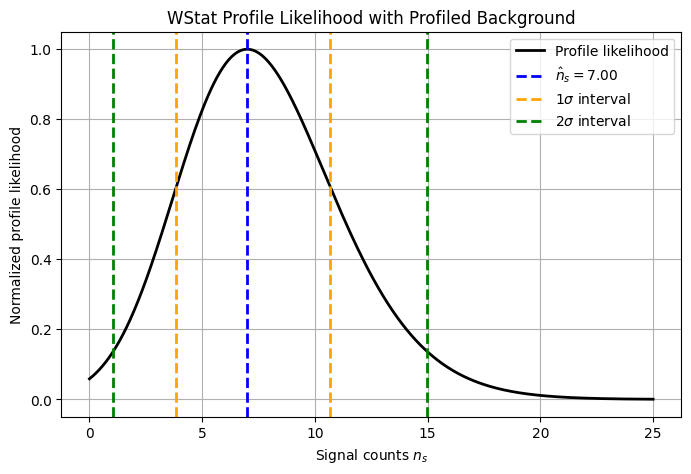

In [24]:
N_on  = 10.0
N_off = 6.0
alpha = 0.5
# -----------------------------
# Global MLE from analytic derivation
# -----------------------------
n_s_hat = max(0.0, N_on - alpha * N_off)
n_off_hat = N_off

# Excess = best-fit signal counts
excess = n_s_hat

C_best = C_wstat(n_s_hat, n_off_hat,N_on,N_off,alpha)

# -----------------------------
# Profile over n_off for fixed n_s using Minuit
# -----------------------------
def profile_n_off(n_s_fixed):
    def C_fixed(n_off):
        return C_wstat(n_s_fixed, n_off,N_on,N_off,alpha)

    m = Minuit(C_fixed, n_off=N_off)
    m.limits["n_off"] = (1e-9, None)
    m.migrad()

    return m.values["n_off"], m.fval

# -----------------------------
# Scan over n_s values
# -----------------------------
n_s_vals = np.linspace(0, 25, 1000)

q_vals = []
n_off_profile_vals = []

for n_s in n_s_vals:
    n_off_prof, C_prof = profile_n_off(n_s)

    n_off_profile_vals.append(n_off_prof)

    # Profile likelihood-ratio statistic
    q = 2.0 * (C_prof - C_best)
    q_vals.append(q)

q_vals = np.array(q_vals)
n_off_profile_vals = np.array(n_off_profile_vals)

# -----------------------------
# Normalized profile likelihood
# L_profile / L_max = exp(-q/2)
# -----------------------------
profile_likelihood = np.exp(-0.5 * q_vals)

# -----------------------------
# Confidence intervals
# -----------------------------

# 1 sigma: q <= 1
ci_1sigma = n_s_vals[q_vals <= 1.0]

# 2 sigma: q <= 4
ci_2sigma = n_s_vals[q_vals <= 4.0]

n_s_1sigma_low = ci_1sigma[0]
n_s_1sigma_high = ci_1sigma[-1]

n_s_2sigma_low = ci_2sigma[0]
n_s_2sigma_high = ci_2sigma[-1]


print(f"1 sigma confidence interval: [{n_s_1sigma_low:.2f}, {n_s_1sigma_high:.2f}]")
print(f"2 sigma confidence interval: [{n_s_2sigma_low:.2f}, {n_s_2sigma_high:.2f}]")

# -----------------------------
# Plot likelihood profile
# -----------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    n_s_vals,
    profile_likelihood,
    color="black",
    linewidth=2,
    label="Profile likelihood"
)

# Best-fit value
plt.axvline(
    n_s_hat,
    color="blue",
    linestyle="--",
    linewidth=2,
    label=rf"$\hat{{n}}_s = {n_s_hat:.2f}$"
)

# 1 sigma interval
plt.axvline(
    n_s_1sigma_low,
    color="orange",
    linestyle="--",
    linewidth=2,
    label=r"$1\sigma$ interval"
)
plt.axvline(
    n_s_1sigma_high,
    color="orange",
    linestyle="--",
    linewidth=2
)

# 2 sigma interval
plt.axvline(
    n_s_2sigma_low,
    color="green",
    linestyle="--",
    linewidth=2,
    label=r"$2\sigma$ interval"
)
plt.axvline(
    n_s_2sigma_high,
    color="green",
    linestyle="--",
    linewidth=2
)

plt.xlabel(r"Signal counts $n_s$")
plt.ylabel("Normalized profile likelihood")
plt.title("WStat Profile Likelihood with Profiled Background")
plt.legend()
plt.grid(True)
plt.show()

## Making use of the nll_on_off function already defined in previous cell $N_{on} = 5.0$ and $N_{off} = 6.0$

Excess: 2.00
 significance of detection: 0.83 sigma
5 sigma upper limit: 23.16


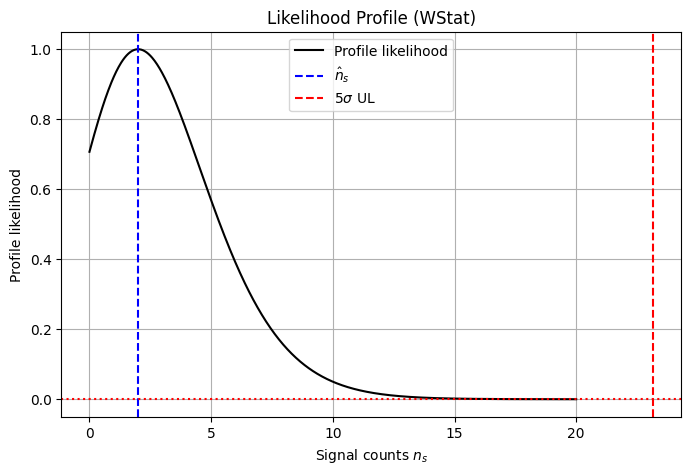

In [25]:
N_on  = 5.0
N_off = 6.0
alpha = 0.5

# -----------------------------
# Global MLE (analytic)
# -----------------------------
n_s_hat  = max(0.0, N_on - alpha * N_off)
n_off_hat = N_off

excess = n_s_hat

# Use existing C_wstat
C_best = C_wstat(n_s_hat, n_off_hat,N_on,N_off,alpha)

# -----------------------------
# Background-only hypothesis
# -----------------------------
n_off_hat_0 = (N_on + N_off)/(1 + alpha)

C_null = C_wstat(0.0, n_off_hat_0,N_on,N_off,alpha)

lambda_0 = 2*(C_null - C_best)

# significance
p = 1.0 - sp.stats.chi2.cdf(lambda_0, df=1)
S = sp.stats.norm.isf(p/2.0)

print(f"Excess: {excess:.2f}")
print(f" significance of detection: {S:.2f} sigma")

n_s_vals = np.linspace(0, 20, 800)
q_vals = []

for n_s in n_s_vals:
    n_off_p, C_prof = profile_n_off(n_s)
    q_vals.append(2*(C_prof - C_best))

q_vals = np.array(q_vals)

# -----------------------------
# Likelihood profile
# -----------------------------
profile_likelihood = np.exp(-0.5 * q_vals)

# -----------------------------
# 5 sigma upper limit
# -----------------------------

from scipy.optimize import brentq

# Define q(n_s) using profiling
def q_profile(n_s):
    n_off_p, C_prof = profile_n_off(n_s)
    return 2.0 * (C_prof - C_best)

# Solve q(n_s) = 25 for 5 sigma upper limit
n_s_ul_5sigma = brentq(lambda x: q_profile(x) - 25.0, n_s_hat, 100.0)

print(f"5 sigma upper limit: {n_s_ul_5sigma:.2f}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(n_s_vals, profile_likelihood, color='black', label='Profile likelihood')

# Best-fit
plt.axvline(n_s_hat, color='blue', linestyle='--', label=r'$\hat{n}_s$')

# 5σ UL
plt.axvline(n_s_ul_5sigma, color='red', linestyle='--', label=r'$5\sigma$ UL')

# 5σ level
plt.axhline(np.exp(-25/2), color='red', linestyle=':')

plt.xlabel(r"Signal counts $n_s$")
plt.ylabel("Profile likelihood")
plt.title("Likelihood Profile (WStat)")
plt.legend()
plt.grid(True)
plt.show()

## comment on the difference between two likelihood
When the estimated signal is smaller than the expected background contribution, it becomes difficult to confidently interpret the observation as a real signal. In such a situation, the data is largely consistent with background fluctuations, and therefore instead of claiming a detection, we place an upper bound on the possible signal strength at a chosen confidence level. On the other hand, when the observed excess significantly exceeds the expected background, it provides stronger evidence for the presence of a signal. In that case, we can determine tighter confidence intervals for the signal, which can be compared and validated against results from other experiments.

In the case of the CStat formulation, the likelihood depends on only a single unknown parameter, namely the signal strength, since the background is assumed to be known. This makes the analysis relatively straightforward. However, in the WStat formulation, the background is not known a priori and must be estimated from data. As a result, the likelihood depends on two unknown parameters: the signal expectation and the background expectation from the OFF region. This introduces an additional Poisson term in the likelihood. To handle this, the background parameter is treated as a nuisance parameter and is eliminated through profiling. Consequently, the confidence intervals for the signal are obtained using the profile likelihood approach, guided by Wilks’ theorem.

## Question 3. 
You are given a 1D signal composed of multiple Gaussian pulses with different widths. Study how convolution with a top-hat (boxcar) kernel of varying radii affects the detectability of these pulses. Create a Jupyter notebook showing in detail:

- Construct a 1D time series with sufficient resolution (decide binning etc. yourself).

- Generate a signal consisting of multiple Gaussian pulses. Choose at least 4 pulses of different widths  
  $ \sigma = [0.01, 0.1, 1, 10] $
  and place them at different positions in time. You may keep amplitudes the same.

- Define top-hat kernels of different radii and convolve them with the signal.

- How does the kernel radius compare to the Gaussian width? Interpret your results.

- Compute the Fourier transform of the signal and the kernel. Interpret.

## ANSWER 3:

In [26]:
#constructing 1d time series 
t_min = 0
t_max = 100

# resolution (important: high enough to resolve σ = 0.01)
dt = 0.001  

t = np.arange(t_min, t_max, dt) #time array

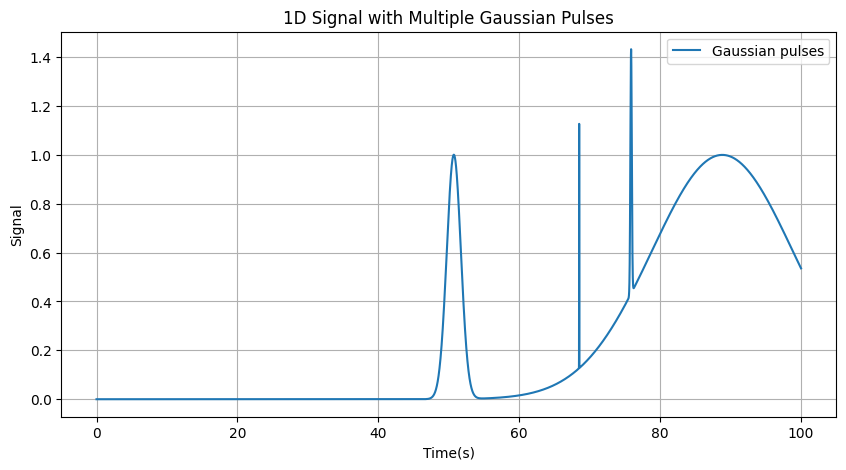

In [27]:
#Genertaing Gaussain pulses 

#  Define Gaussian function -----
def gaussian(t, t0, sigma, A=1):
    return A * np.exp(-(t - t0)**2 / (2 * sigma**2))

# ----- Given widths -----
sigmas = [0.01, 0.1, 1, 10]

# ----- Positions of pulses -----
positions =  np.random.choice(t, 4) # Four randomly positioned Gaussian pulses

# ----- Construct signal -----
signal = np.zeros(len(t))

for sigma, t0 in zip(sigmas, positions):
    signal += gaussian(t, t0, sigma)

# ----- Plot -----
plt.figure(figsize=(10, 5))
plt.plot(t, signal, label='Gaussian pulses')

plt.xlabel('Time(s)')
plt.ylabel('Signal')
plt.title('1D Signal with Multiple Gaussian Pulses')
plt.legend()
plt.grid()
plt.show()

A top-hat kernel is a flat window. It is equal to a constant value inside some radius and zero outside.
For radius R, we can write:
$K(t)=\frac{1}{2R}$ for $|t|\le R$
and
$K(t)=0$ for $|t|>R$
The factor $\frac{1}{2R}$ is used so that the total area of the kernel is 1. In discrete code, we normalize by dividing by the sum.
Convolution means sliding this top-hat window over the signal and replacing each point by a local average around it. So it smooths the signal. If the kernel radius is small, sharp pulses survive. If the kernel radius is large, sharp pulses get washed out.

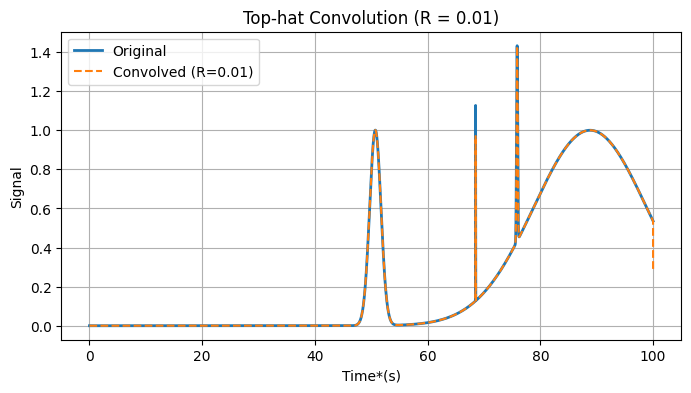

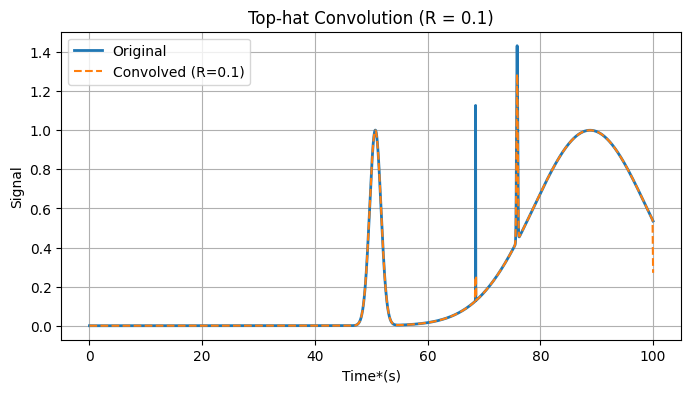

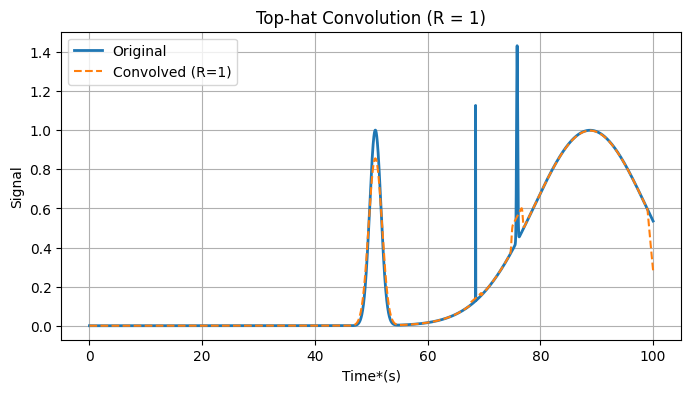

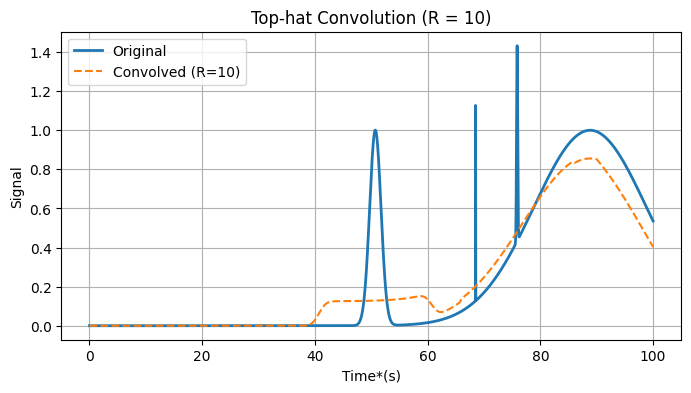

In [28]:
# Defining top-hat kernel
def top_hat_kernel(radius, dt):
    n_bins = int(radius / dt)
    kernel = np.ones(2 * n_bins + 1)
    kernel /= np.sum(kernel)
    return kernel

# ----- Radii -----
radii = [0.01, 0.1, 1, 10]

# ----- Plot separately -----
for R in radii:
    kernel = top_hat_kernel(R, dt)
    conv_signal = np.convolve(signal, kernel, mode='same')

    plt.figure(figsize=(8,4))
    plt.plot(t, signal, label='Original', linewidth=2)
    plt.plot(t, conv_signal, label=f'Convolved (R={R})', linestyle='--')

    plt.xlabel('Time*(s)')
    plt.ylabel('Signal')
    plt.title(f'Top-hat Convolution (R = {R})')
    plt.legend()
    plt.grid()
    plt.show()

## Interpretation:
When the kernel radius is $0.01$, the convolved signal almost completely overlaps with the original signal. This happens because the kernel width is very small and comparable to the narrowest Gaussian. Only for that particular peak, where the kernel size matches the Gaussian width, a slight reduction in peak height is observed. For the other wider Gaussians, the overlap remains nearly perfect.

As the kernel radius increases to $0.1$, the effect of smoothing becomes more noticeable. The narrowest Gaussian peak (with width $0.01$) is now significantly suppressed after convolution. However, the Gaussian with width $0.1$ still shows a reasonable overlap between the original and convolved signals.

When the radius is increased further to $1$, most of the narrower peaks get strongly suppressed. Only the Gaussian whose width is close to $1$ retains a similar amplitude, while the wider peaks begin to show smoothing effects.

For a large radius like $10$, almost all the narrower Gaussians are washed out due to strong smoothing, and only the widest Gaussian remains clearly visible.

Thus, applying a top-hat kernel effectively acts as a filter that selects signals based on their characteristic width. By choosing an appropriate kernel size, we can isolate signals of interest. For example, if we are interested in broader features, a larger kernel radius like $10$ is useful.

If the goal is to study narrower signals, we can start with a large kernel to capture broad features, then gradually reduce the kernel radius to reveal finer structures. In practice, since the widths of signals are not known beforehand, one needs to scan over different kernel sizes to understand how different components contribute to the observed signal.

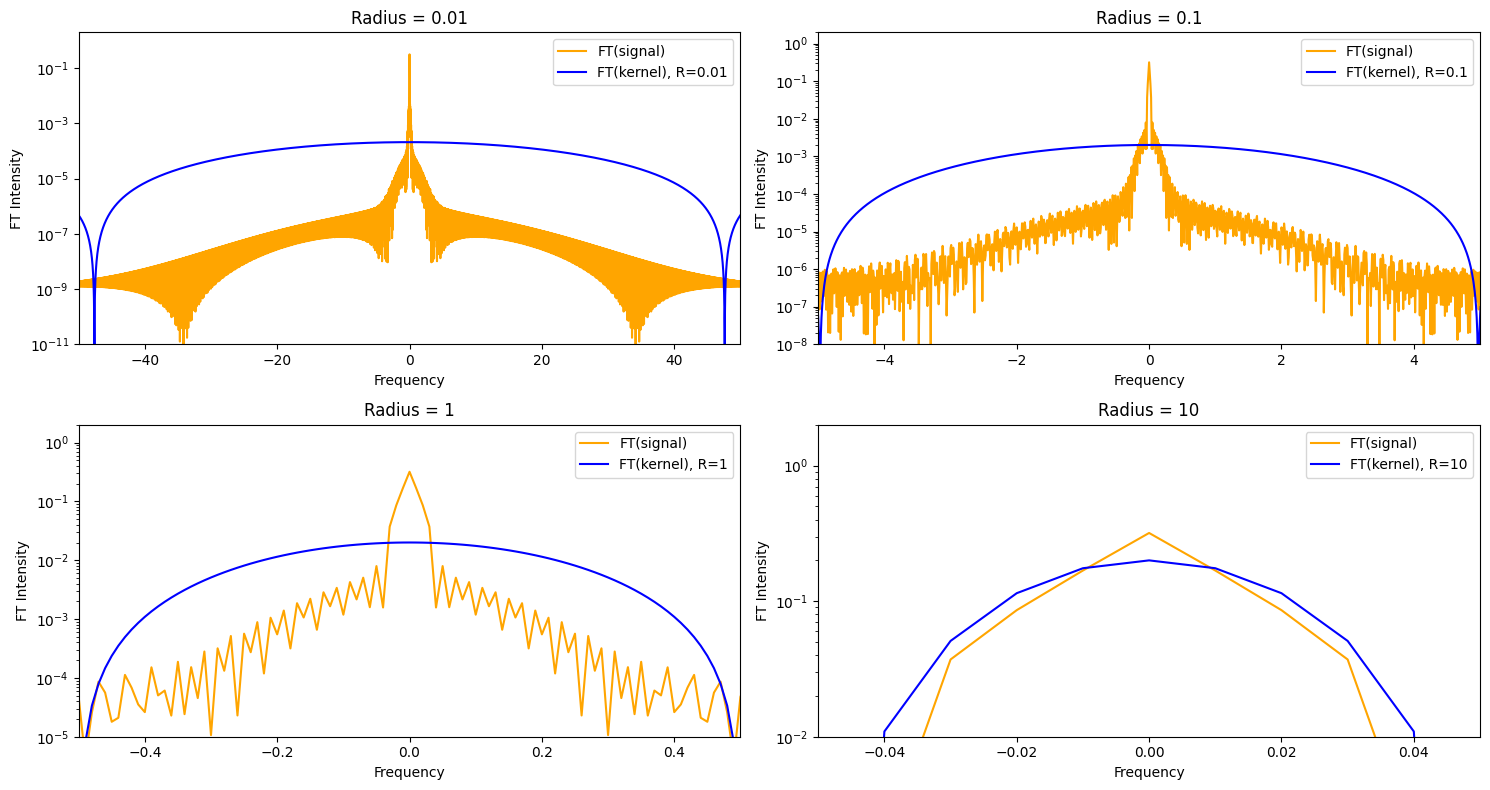

In [29]:
# Plotting signal FFT and kernel

freq_shifted = np.fft.fftshift(np.fft.fftfreq(len(t), dt))

ft_signal = np.fft.fftshift(np.fft.fft(signal))

# Taking |FT|^2 and normalizing for visual comparison
ft_signal_norm = np.abs(ft_signal)**2 / np.trapezoid(np.abs(ft_signal)**2)

fig, ax = plt.subplots(2, 2, figsize=(15, 8))

# subplot index positions for 5 radii
ik = [(0, 0), (0, 1), (1, 0), (1, 1)]

for r_i in range(len(radii)):

    radius = radii[r_i]
    i, k = ik[r_i]

    # make top-hat kernel
    ker = top_hat_kernel(radius, dt)

    # pad kernel to same length as signal
    ker_padded = np.zeros_like(signal)
    ker_padded[:len(ker)] = ker

    # FFT of kernel
    ft_ker = np.fft.fftshift(np.fft.fft(ker_padded))

    # Taking |FT|^2 and normalizing
    ft_ker_norm = np.abs(ft_ker)**2 / np.trapezoid(np.abs(ft_ker)**2)

    freq_cut = 0.5 / radius

    # Semilog plot
    ax[i, k].semilogy(freq_shifted, ft_signal_norm, color='orange', label='FT(signal)')
    ax[i, k].semilogy(freq_shifted, ft_ker_norm, color='blue', label=f'FT(kernel), R={radius}')

    ax[i, k].legend()
    ax[i, k].set_xlabel("Frequency")
    ax[i, k].set_ylabel("FT Intensity")
    ax[i, k].set_title(f"Radius = {radius}")

    # Dynamic clipping
    ax[i, k].set_xlim(-freq_cut, freq_cut)

    # Dynamic lower y-limit
    ax[i, k].set_ylim(1e-11 * (10.0)**(3 * r_i), 2.0)

plt.tight_layout()
plt.show()

## Interpretation:
The plots highlight the central region of the Fourier transform of the top-hat kernel for different choices of the radius. For the smallest radius, $R = 0.01$, the Fourier transform of the kernel remains nearly flat over a very wide frequency range. This range comfortably includes all the frequency components present in the Fourier transform of the signal. As a result, when the kernel and signal are multiplied in Fourier space, the signal is almost unchanged. This explains why, in real space, the convolution with such a narrow kernel reproduces the original signal with only minor distortions, mainly around the sharpest peaks where the Gaussian width becomes comparable to the kernel size.

When the radius is increased to $R = 0.1$, the situation changes. The central lobe of the kernel’s Fourier transform becomes narrower and now overlaps only with the lower-frequency part of the signal. Frequencies higher than this range are no longer supported and are effectively suppressed. In this case, the kernel starts behaving like a low-pass filter, allowing only slower variations in the signal to pass through while damping the rapid fluctuations.

For $R = 1$, this filtering becomes even more pronounced. The central lobe shrinks further, meaning that only a limited band of low frequencies in the signal survives. Most of the higher-frequency components, which correspond to sharper features in the time domain, are removed after multiplication in Fourier space. Consequently, in the convolved signal, only the broader structures remain visible.

In the extreme case of $R = 10$, the Fourier transform of the kernel is highly concentrated around very low frequencies. Almost all higher-frequency components of the signal are filtered out, leaving behind only the slowest varying (broadest) part of the signal. This matches the real-space observation where only the widest Gaussian pulse survives after convolution, while all narrower features disappear.

From these observations, we can conclude that the top-hat kernel acts as a low-pass filter. Its effective cutoff frequency scales as $f_{\text{cut}} \sim \frac{1}{2R}$. A Gaussian pulse will remain visible after filtering only if its characteristic frequency is below this cutoff. In terms of the pulse width $\sigma$, this roughly translates to the condition $R \lesssim \pi \sigma$. If this condition is not satisfied, the corresponding signal component is strongly suppressed.

# Question 4:

Redo the above by adding a Poisson noise on the time series. You can interpret it then as the number of detected counts from a certain object. Add slowly varying background on top. This is very similar to what we observe in blazar flares, and can be generalised to a study of flare detections.

## ANSWER 4:
To do Question 4, we follow the same idea as Question 3, but now we make the time series closer to a real observation.
In Question 3, the signal was a smooth function made from Gaussian pulses:
$ \text{signal}(t) = \text{sum of Gaussian pulses} $
Here, the Gaussian pulses again represent flare-like events. First, we construct the signal using four Gaussian pulses with different widths,
$ \sigma = [0.01, 0.1, 1, 10] $
placed at different positions in time.
In real gamma-ray observations, however, we do not directly observe this smooth signal. We observe discrete photon counts. Since photon counting follows Poisson statistics, we convert the smooth signal into noisy counts using
$ \text{noisy_signal}(t) \sim \text{Poisson}(\text{signal}(t)\times \text{count_rate}) $
Then we add a slowly varying background. In the code, this is chosen as
$ \text{background}(t) = \sin\left(\frac{2\pi t}{100}\right) $
This background changes slowly compared to the sharp Gaussian pulses.
Finally, the total observed counts are written as
$ \text{observed_counts}(t) = \text{noisy_signal}(t) + \text{background}(t) $
So the full procedure is:
$ \text{smooth Gaussian signal} \rightarrow \text{Poisson noisy signal} \rightarrow \text{add slow background} \rightarrow \text{observed counts} $

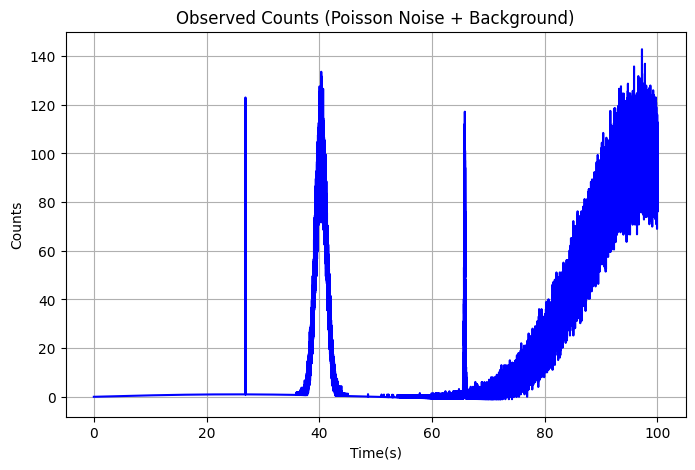

In [30]:
# ----- Time series -----
t_min, t_max = 0, 100
dt = 0.001
t = np.arange(t_min, t_max, dt)

# ----- Gaussian function -----
def gaussian(t, t0, sigma, A=1):
    return A * np.exp(-(t - t0)**2 / (2 * sigma**2))

# ----- Signal (same as Q3) -----
sigmas = [0.01, 0.1, 1, 10]
positions = np.random.choice(t, 4)

signal = np.zeros_like(t)

for sigma, t0 in zip(sigmas, positions):
    signal += gaussian(t, t0, sigma)

# ----- Convert to counts (Poisson noise) -----
count_rate = 100
noisy_signal = np.random.poisson(signal * count_rate)

# ----- Slowly varying background -----
background = 1.0 * np.sin(2 * np.pi * t / 100)

# ----- Total observed counts -----
observed_counts = noisy_signal + background

# ----- Plot -----
plt.figure(figsize=(8, 5))
plt.plot(t, observed_counts, color="blue")
plt.xlabel("Time(s)")
plt.ylabel("Counts")
plt.title("Observed Counts (Poisson Noise + Background)")
plt.grid()
plt.show()

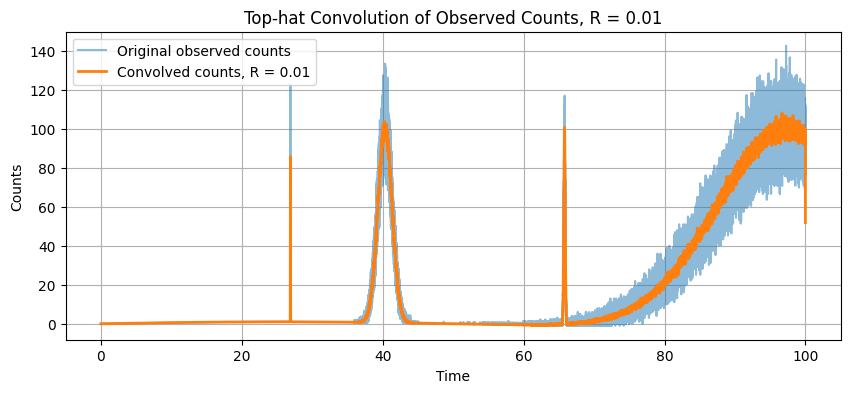

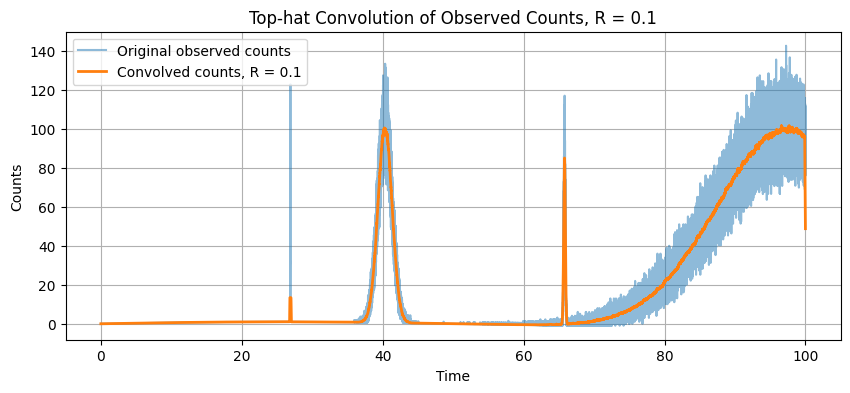

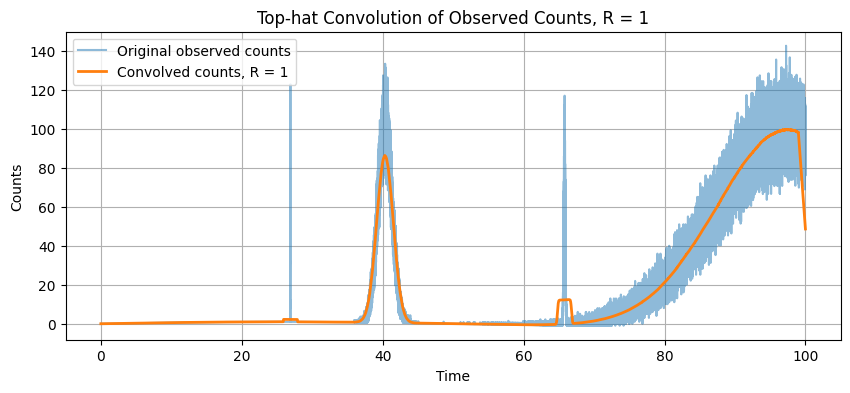

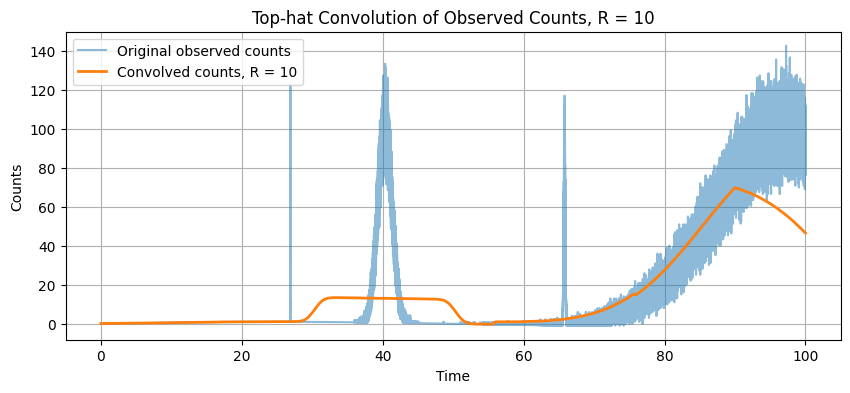

In [31]:
# ----- Top-hat kernel function ----- we defined in question 3 
#radii we defined in question 3 
# ----- Convolve observed counts and plot separately -----
for R in radii:
    kernel = top_hat_kernel(R, dt)

    convolved_counts = np.convolve(observed_counts, kernel, mode="same")

    plt.figure(figsize=(10, 4))

    plt.plot(t, observed_counts, label="Original observed counts", alpha=0.5)
    plt.plot(t, convolved_counts, label=f"Convolved counts, R = {R}", linewidth=2)

    plt.xlabel("Time")
    plt.ylabel("Counts")
    plt.title(f"Top-hat Convolution of Observed Counts, R = {R}")
    plt.legend()
    plt.grid()
    plt.show()

## Interpretation:
From the plots, it is clear that increasing the radius of the top-hat kernel leads to a smoother version of the observed counts. The random fluctuations present in the data gradually decrease as the kernel size grows. This behavior can be understood by noting that the kernel effectively removes high-frequency components of the signal.

Since Poisson noise is distributed across all frequencies, especially at higher frequencies, it gets progressively suppressed when the kernel radius is increased. As a result, the convolved signal appears less noisy and the broader structures in the data become more prominent.

This trend is visually evident, as the jagged variations in the counts reduce and the curves become smoother with increasing kernel radius.

However, the slowly varying background remains largely unaffected. This is because its variation occurs at very low frequencies, which are still preserved even when the kernel radius is large. Therefore, the baseline level of the signal continues to follow the background behavior.

At the same time, using a very large kernel also reduces the sharpness of narrower features. While noise is suppressed, some signal details are also smoothed out. In particular, narrower or moderately wide Gaussian pulses become less distinct compared to the case without background. This indicates that choosing the kernel radius involves a balance between reducing noise and preserving signal features.

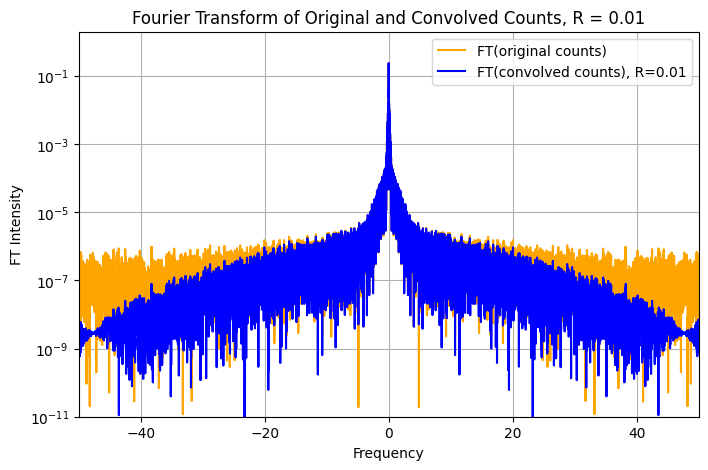

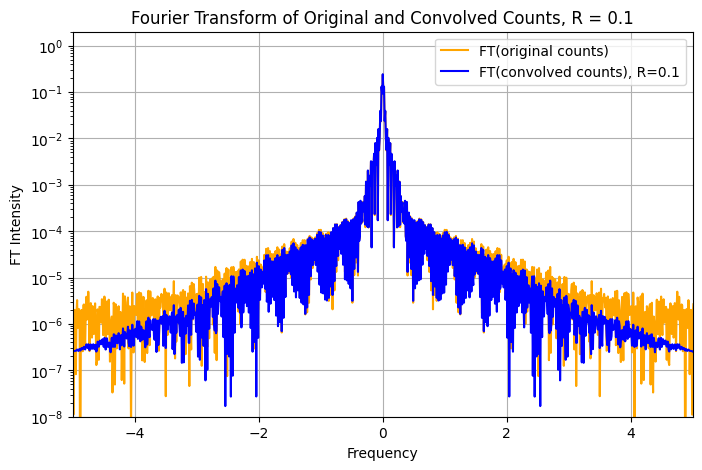

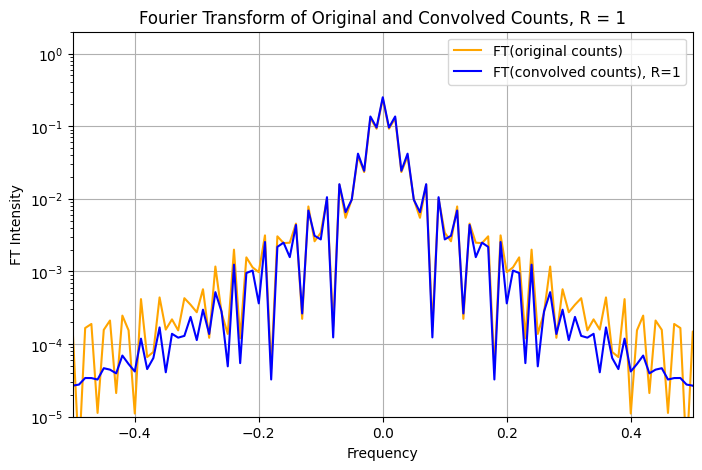

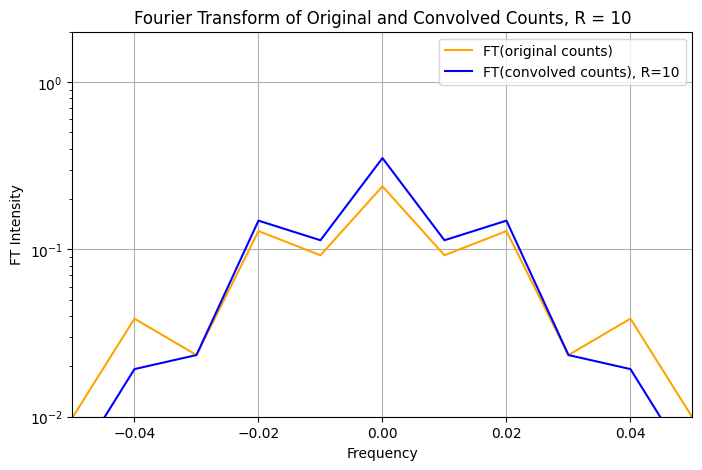

In [32]:
# Plotting observation FFT and kernel FFT 
# ----- Frequency axis -----
freq_shifted = np.fft.fftshift(np.fft.fftfreq(len(t), dt))

# ----- FFT of original observed counts -----
ft_original = np.fft.fftshift(np.fft.fft(observed_counts))

# Power spectrum and normalization
ft_original_norm = np.abs(ft_original)**2 / np.trapezoid(np.abs(ft_original)**2)

# ----- Radii -----
radii = [0.01, 0.1, 1, 10]

for r_i, R in enumerate(radii):

    # Top-hat kernel
    kernel = top_hat_kernel(R, dt)

    # Convolved counts
    convolved_counts = np.convolve(observed_counts, kernel, mode="same")

    # FFT of convolved counts
    ft_convolved = np.fft.fftshift(np.fft.fft(convolved_counts))

    # Power spectrum and normalization
    ft_convolved_norm = np.abs(ft_convolved)**2 / np.trapezoid(np.abs(ft_convolved)**2)

    # Frequency cut, same idea as Q3
    freq_cut = 0.5 / R

    plt.figure(figsize=(8, 5))

    plt.semilogy(freq_shifted, ft_original_norm, label="FT(original counts)", color="orange")
    plt.semilogy(freq_shifted, ft_convolved_norm, label=f"FT(convolved counts), R={R}", color="blue")

    plt.xlabel("Frequency")
    plt.ylabel("FT Intensity")
    plt.title(f"Fourier Transform of Original and Convolved Counts, R = {R}")
    plt.legend()
    plt.grid()

    # Restrict x-axis to central frequency window

    plt.xlim(-freq_cut, freq_cut)

    # Dynamic y-axis limit
    plt.ylim(1e-11 * (10.0)**(3 * r_i), 2.0)

    plt.show()

## Interpretation:
The low-frequency components of the signal remain unchanged after convolution, as seen from the overlap between the Fourier transforms of the original and convolved counts in that region. This indicates that the kernel preserves low-frequency information while suppressing higher-frequency components. For small radius, such as $R = 0.01$, the cutoff frequency $f_{\text{cut}} \sim \frac{1}{2R}$ is large. So almost all frequencies of the original signal lie within this range, and the Fourier transform of the convolved counts is very similar to that of the original counts. This means very little filtering occurs.

As the radius increases to $R = 0.1$ and $R = 1$, the cutoff frequency decreases. Now, only the lower frequency components survive, while higher frequency components are reduced. This leads to suppression of noise, since noise mainly contributes at higher frequencies.

For large radius value $R = 10$, the cutoff frequency becomes very small. In this case, most of the high-frequency components are removed, and only the very low-frequency part of the signal remains. This corresponds to strong smoothing in the time domain, where only broad structures are visible. 
Thus, the Fourier plots clearly show that the top-hat kernel acts as a low-pass filter. Increasing the kernel radius reduces the frequency bandwidth, which suppresses high-frequency noise while preserving the low-frequency components. This is seen from the fact that the Fourier transforms of the original and convolved counts overlap in the low-frequency region but differ significantly at higher frequencies. Therefore, there is a balance between noise reduction and preserving important signal features.

## Question 5. 
Generalise (3) to source detections. Use Gammapy to simulate a 2D gamma-ray sky with sources of different spatial extensions and analyze it using ExcessMapEstimator and TSMapEstimator. Simulate a point source (PSF limited) and sources of different Gaussian widths. Follow for simulation and to understand how to use the estimators.

- For each radii, plot the TS and excess maps, and identify statistically significant signals.

- Discuss your results.

- What is the difference in interpretation between the two estimators? Which one will you prefer for claiming source detections?

In [6]:
# Necessary imports as I did assignment 1

from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time   # For siumlating observation
from IPython.display import display
import gammapy
from gammapy.data import DataStore, Observation  # Dealing with telescope data and IRFs and simulating observation
from gammapy.datasets import MapDataset
from gammapy.estimators import ExcessMapEstimator, TSMapEstimator   # Estimators to be used
from gammapy.maps import MapAxis, WcsGeom, Map  # For defining sky geometry
from gammapy.makers import MapDatasetMaker, SafeMaskMaker
from gammapy.modeling.models import SkyModel, PowerLawSpectralModel, PointSpatialModel, GaussianSpatialModel, Models

In [7]:
import os
print(os.environ.get("GAMMAPY_DATA"))  # should not be None

C:\Users\goura\gammapy-data


In [9]:
# --------------------------------------------------
# Constructing the sky geometry
# --------------------------------------------------
energy_bins=MapAxis.from_energy_bounds("1 TeV","10 TeV",nbin=1)
sky_center=SkyCoord(0.0,0.0,unit="deg",frame="galactic")
sky_geom=WcsGeom.create(skydir=sky_center,binsz=0.02,width=(5,5),frame="galactic",axes=[energy_bins])
# --------------------------------------------------
# Loading HESS instrument response information
# --------------------------------------------------
hess_store=DataStore.from_dir("$GAMMAPY_DATA/hess-dl3-dr1/")
reference_observation=hess_store.obs(obs_id=23523)
response_functions={"aeff":reference_observation.aeff,"psf":reference_observation.psf,"bkg":reference_observation.bkg,"edisp":reference_observation.edisp}
# --------------------------------------------------
# Creating a simulated observation
# --------------------------------------------------
observation_time=12*u.hour
fake_observation=Observation.create(obs_id=101,pointing=sky_center,livetime=observation_time,irfs=response_functions)
# --------------------------------------------------
# Defining source locations
# --------------------------------------------------
source_locations=[SkyCoord(0.0,0.0,unit="deg",frame="galactic"),SkyCoord(1.0,0.0,unit="deg",frame="galactic"),SkyCoord(0.0,1.0,unit="deg",frame="galactic"),
                  SkyCoord(-1.0,0.0,unit="deg",frame="galactic"),
                  SkyCoord(0.0,-1.0,unit="deg",frame="galactic")]
source_sizes=[None,0.05,0.10,0.20,0.40]
all_models=[]

# --------------------------------------------------
# Constructing source models
# --------------------------------------------------
for idx,spread in enumerate(source_sizes):
    source_position=source_locations[idx]
    source_spectrum=PowerLawSpectralModel(index=2.5,amplitude=5e-12*u.Unit("cm-2 s-1 TeV-1"),reference=1*u.TeV)
    if spread is None:
        spatial_component=PointSpatialModel(lon_0=source_position.galactic.l,lat_0=source_position.galactic.b,frame="galactic")
        model_name=f"point_source_{idx}"
    else:
        spatial_component=GaussianSpatialModel(lon_0=source_position.galactic.l,lat_0=source_position.galactic.b,sigma=spread*u.deg,frame="galactic")
        model_name=f"gaussian_source_sigma_{spread}"
    source_model=SkyModel(spectral_model=source_spectrum,spatial_model=spatial_component,name=model_name)
    all_models.append(source_model)
combined_models=Models(all_models)
# --------------------------------------------------
# Building dataset
# --------------------------------------------------
blank_dataset=MapDataset.create(geom=sky_geom,name="gamma_ray_simulation")
dataset_builder=MapDatasetMaker(selection=["exposure","background","psf","edisp"])
mask_builder=SafeMaskMaker(methods=["offset-max"],offset_max=2.5*u.deg)
simulated_data=dataset_builder.run(blank_dataset,observation=fake_observation)
simulated_data=mask_builder.run(simulated_data,fake_observation)
simulated_data.models=combined_models
# Generate Poisson fluctuated counts
simulated_data.fake()
# --------------------------------------------------
# Plotting simulated counts map
# --------------------------------------------------
fig,ax=plt.subplots(figsize=(8,6))
simulated_data.counts.sum_over_axes().plot(ax=ax,add_cbar=True)
ax.set_title("Simulated Gamma-ray Sky")
plt.show()



OSError: File not found: C:\Users\goura\gammapy-data\hess-dl3-dr1\hdu-index.fits.gz

In [11]:
# --------------------------------------------------
# Excess significance maps for different smoothing radii
# --------------------------------------------------
smooth_radii=[0.05,0.1,0.2,0.4]*u.deg
excess_results={}
excess_dataset=simulated_data.copy()
excess_dataset.models=Models([])
for radius_val in smooth_radii:
    excess_estimator=ExcessMapEstimator(correlation_radius=radius_val)
    excess_output=excess_estimator.run(excess_dataset)
    excess_results[radius_val.value]=excess_output
    print(f"Radius={radius_val}: max significance={np.nanmax(excess_output['sqrt_ts'].data):.2f}, max excess counts={np.nanmax(excess_output['npred_excess'].data):.1f}")
# --------------------------------------------------
# Plotting significance maps
# --------------------------------------------------
fig,axs=plt.subplots(2,2,figsize=(12,10))
plot_index=[(0,0),(0,1),(1,0),(1,1)]
for idx,radius_val in enumerate(smooth_radii):
    row,col=plot_index[idx]
    significance_map=excess_results[radius_val.value]["sqrt_ts"]
    significance_map.sum_over_axes().plot(ax=axs[row,col],add_cbar=True,cmap="magma")
    axs[row,col].contour(significance_map.sum_over_axes().data.squeeze(),levels=[3,5],colors=["cyan","white"])
    axs[row,col].set_title(f"Excess Significance Map, R={radius_val}")
plt.tight_layout()
plt.show()

NameError: name 'simulated_data' is not defined

In [12]:
# --------------------------------------------------
# TS significance maps for different test source models
# --------------------------------------------------
ts_dataset=simulated_data.copy()
ts_dataset.models=Models([])
sigma_trials=[None,0.05,0.1,0.2,0.4]
ts_outputs={}
for sigma_val in sigma_trials:
    if sigma_val is None:
        spatial_trial=PointSpatialModel()
        kernel_size=0.2*u.deg
        sigma_label="point"
    else:
        spatial_trial=GaussianSpatialModel(sigma=sigma_val*u.deg)
        kernel_size=4*sigma_val*u.deg
        sigma_label=f"{sigma_val}"
    test_model=SkyModel(spectral_model=PowerLawSpectralModel(),spatial_model=spatial_trial)
    ts_estimator=TSMapEstimator(model=test_model,kernel_width=kernel_size)
    ts_result=ts_estimator.run(ts_dataset)
    ts_outputs[sigma_label]=ts_result
    print(f"Test sigma={sigma_label}: maximum TS={np.nanmax(ts_result['ts'].data):.1f}")
# --------------------------------------------------
# Plotting TS maps
# --------------------------------------------------
fig,axs=plt.subplots(2,3,figsize=(18,10))
axs=axs.flatten()
for idx,(sigma_label,ts_result) in enumerate(ts_outputs.items()):
    ts_map=ts_result["ts"]
    significance_contour=ts_result["sqrt_ts"]
    max_ts=np.nanmax(ts_map.data)
    ts_map.sum_over_axes().plot(ax=axs[idx],add_cbar=True,cmap="viridis",vmin=0,vmax=max_ts)
    axs[idx].contour(significance_contour.sum_over_axes().data.squeeze(),levels=[3,5],colors=["cyan","white"],linewidths=[1.5,2.0],alpha=0.8)
    axs[idx].set_title(f"TS Map, Kernel={sigma_label}"+("" if sigma_label=="point" else " deg"))
    axs[idx].set_xlabel("Galactic Longitude (deg)")
    axs[idx].set_ylabel("Galactic Latitude (deg)")
axs[-1].set_visible(False)
plt.tight_layout()
plt.show()

NameError: name 'simulated_data' is not defined

### Observations and Interpretations

### ExcessMapEstimator vs TSMapEstimator, Connection to Q3, Detection Criterion

| Property | ExcessMapEstimator | TSMapEstimator |


This property I cannot expalin because zI can not excess the file I tried a lot. But for convenience I gave here the codes.
